#**GFG Adobe Gensolv Hackathon - Curvetopia**

**Task** - Identify, regularize and beautify curves in 2D Euclidean space
Precisely - Build algorithms for Symmetry, Regularization & Curve Completion techniques
where

**Input** = PNG (raster) image of line art

**Output** = set of curves, where curves are defined as connected sequence of cubic Bezier Curves - *format???? (List of polyline points or smthn else??)*

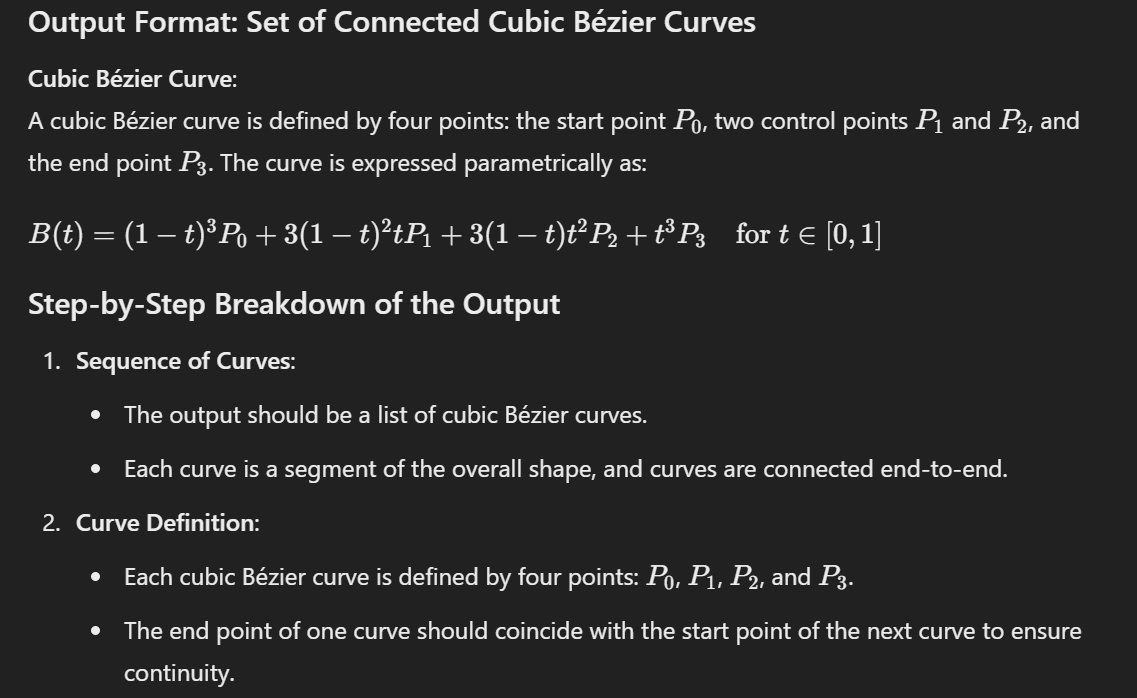

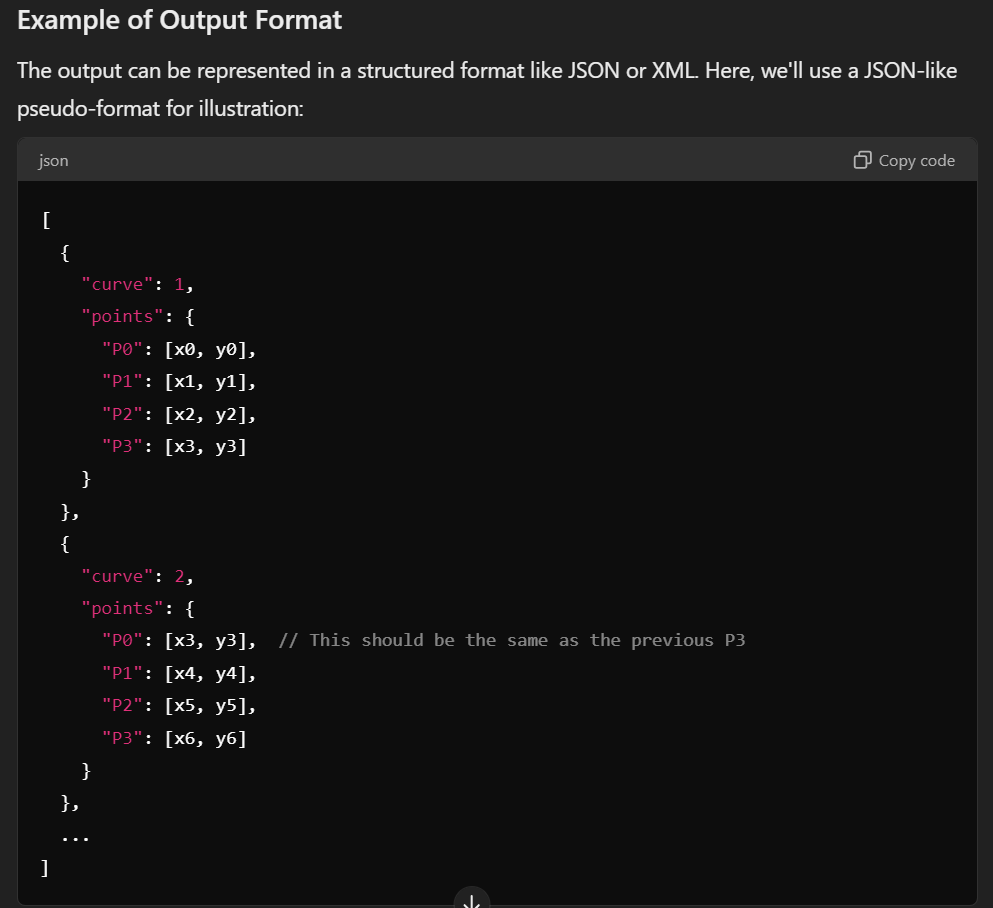


###**STEP 1**
**Regularization** - Identify and regularize common shapes. (The algorithm must be able to distinguish between regularized and non-regularized shapes) where i/p = handwritten images

###**STEP 2**
**Symmetry** - Detect symmetry in the shapes and present the curve as set of points & fit identical Bezier Curves to the symmetric points

###**STEP 3**
**Curve Completion** - Build an algorithm to fill gaps in curves, making them complete based on smoothness, regularity and symmetry. *(for 2D curves that have been 'planarised' - refer PDF to understand)*. i.e;. Create algorithms using Computer vision concepts to compute curves that have gaps due to occlusion removal *(To understand occlusion, refer PDF, don't google it)*

In [ ]:
import numpy as np
def read_csv(csv_path):
  np_path_XYs = np.genfromtxt(csv_path, delimiter = ',')
  path_XYs = []
  for i in np.unique(np_path_XYs[:, 0]):
    npXYs = np_path_XYs[np_path_XYs[:, 0] == i ][:, 1:]
    XYs = []
    for j in np.unique(npXYs [:, 0]):
      XY = npXYs[npXYs[:, 0] == j ][:, 1:]
      XYs.append(XY)
    path_XYs.append(XYs)
  return path_XYs

path_XYs = read_csv("/content/frag2.csv")
len(path_XYs)

26

In [ ]:
import numpy as np
def read_csv(csv_path):
  np_path_XYs = np.genfromtxt(csv_path, delimiter = ',')
  path_XYs = []
  for i in np.unique(np_path_XYs[:, 0]):
    npXYs = np_path_XYs[np_path_XYs[:, 0] == i ][:, 1:]
    XYs = []
    for j in np.unique(npXYs [:, 0]):
      XY = npXYs[npXYs[:, 0] == j ][:, 1:]
      XYs.append(XY)
    path_XYs.append(XYs)
  return path_XYs

path_XYs1 = read_csv("/content/frag2_sol.csv")
len(path_XYs1)

12

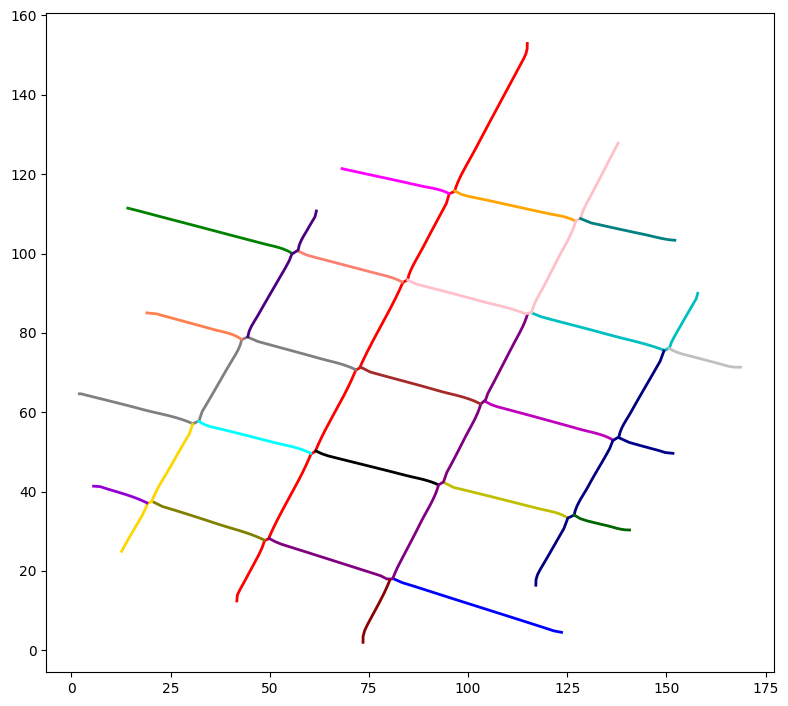

In [ ]:
import numpy as np
import matplotlib . pyplot as plt
def plot(paths_XYs):
  colours = [
    'b', 'g', 'r', 'c', 'm', 'y', 'k',  # Basic colors
    'orange', 'purple', 'brown', 'pink', 'grey', 'olive', 'cyan', 'magenta',  # Extended colors
    'salmon', 'coral', 'teal', 'navy', 'indigo', 'gold', 'silver', 'darkred',  # Additional colors
    'darkblue', 'darkgreen', 'darkviolet', 'lightblue', 'lightgreen', 'lightpink',  # Pastel colors
    'lightgrey', 'lavender', 'beige', 'chocolate'  # Neutral and soft colors
]
  fig, ax = plt.subplots(tight_layout = True, figsize =(8 , 8))
  for i, XYs in enumerate(path_XYs):
    c = colours[i]
    for XY in XYs:
      ax.plot(XY[:, 0], XY[:, 1], c = c, linewidth =2)
  ax.set_aspect('equal')
  plt.show()

plot(path_XYs)

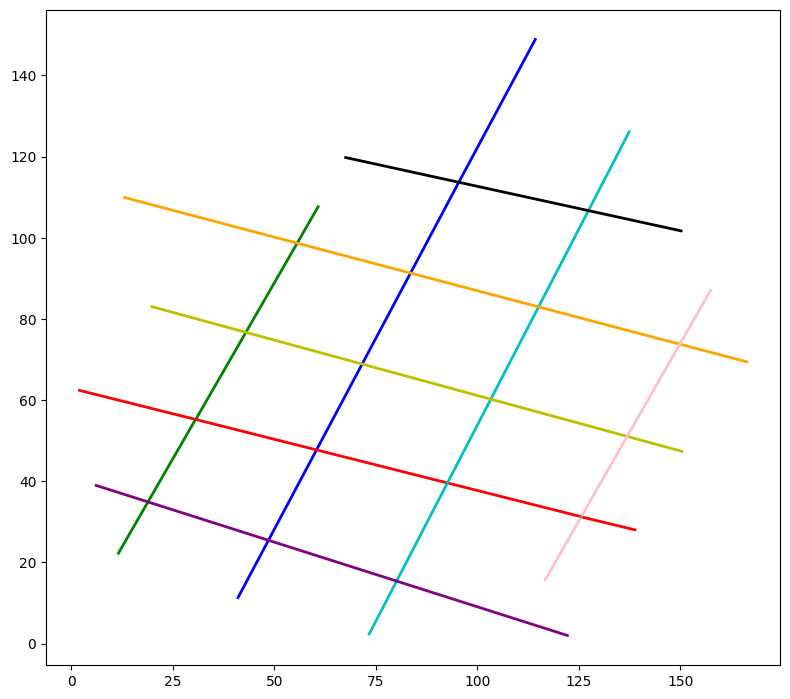

In [ ]:
import numpy as np
import matplotlib . pyplot as plt
def plot(paths_XYs1):
  colours = [
    'b', 'g', 'r', 'c', 'm', 'y', 'k',  # Basic colors
    'orange', 'purple', 'brown', 'pink', 'grey', 'olive', 'cyan', 'magenta',  # Extended colors
    'salmon', 'coral', 'teal', 'navy', 'indigo', 'gold', 'silver', 'darkred',  # Additional colors
    'darkblue', 'darkgreen', 'darkviolet', 'lightblue', 'lightgreen', 'lightpink',  # Pastel colors
    'lightgrey', 'lavender', 'beige', 'chocolate'  # Neutral and soft colors
]
  fig, ax = plt.subplots(tight_layout = True, figsize =(8 , 8))
  for i, XYs in enumerate(path_XYs1):
    c = colours[i]
    for XY in XYs:
      ax.plot(XY[:, 0], XY[:, 1], c = c, linewidth =2)
  ax.set_aspect('equal')
  plt.show()

plot(path_XYs1)

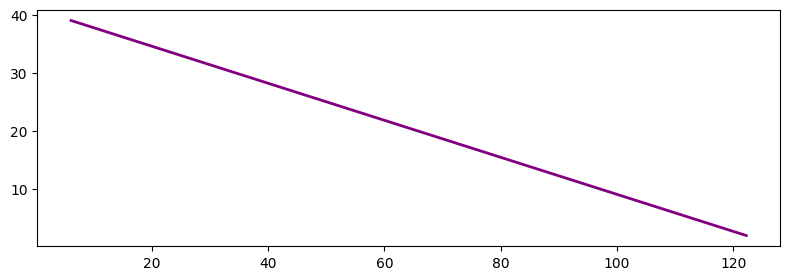

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_first_path(paths_XYs):
    colours = [
    'b', 'g', 'r', 'c', 'm', 'y', 'k',  # Basic colors
    'orange', 'purple', 'brown', 'pink', 'grey', 'olive', 'cyan', 'magenta',  # Extended colors
    'salmon', 'coral', 'teal', 'navy', 'indigo', 'gold', 'silver', 'darkred',  # Additional colors
    'darkblue', 'darkgreen', 'darkviolet', 'lightblue', 'lightgreen', 'lightpink',  # Pastel colors
    'lightgrey', 'lavender', 'beige', 'chocolate'  # Neutral and soft colors
]
    fig, ax = plt.subplots(tight_layout=True, figsize=(8, 8))

    # Plot only the first element of paths_XYs
    XYs = paths_XYs[8]
    c = colours[8]
    for XY in XYs:
        ax.plot(XY[:, 0], XY[:, 1], c=c, linewidth=2)

    ax.set_aspect('equal')
    plt.show()

plot_first_path(path_XYs1)

#**STEP 1 - REGULARIZATION !!**

In [ ]:
!pip install svgpathtools numpy opencv-python opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.9 MB/s eta 0:00:00


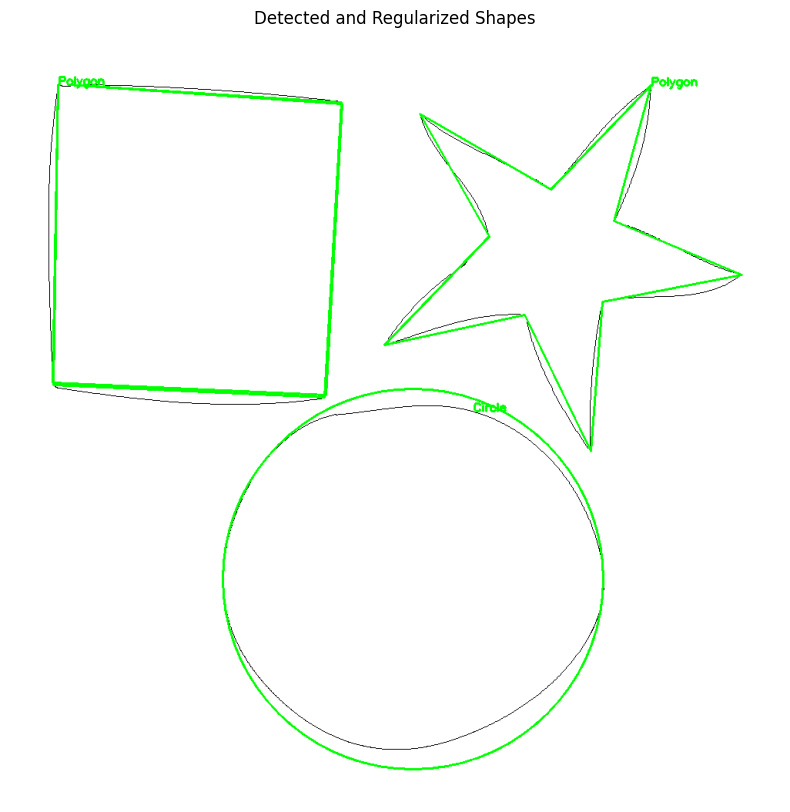

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from svgpathtools import svg2paths
from PIL import Image, ImageDraw

def svg_to_image(svg_file, output_size=(1000, 1000)):
    """Convert SVG file to a PIL image."""
    paths, attributes = svg2paths(svg_file)

    # Find the bounding box of the SVG
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        bounds = path.bbox()
        xmin, xmax = min(xmin, bounds[0]), max(xmax, bounds[1])
        ymin, ymax = min(ymin, bounds[2]), max(ymax, bounds[3])

    # Calculate scaling factor
    svg_width, svg_height = xmax - xmin, ymax - ymin
    scale = min(output_size[0] / svg_width, output_size[1] / svg_height) * 0.9  # 0.9 to add some padding

    # Calculate translation to center the image
    tx = (output_size[0] - svg_width * scale) / 2 - xmin * scale
    ty = (output_size[1] - svg_height * scale) / 2 - ymin * scale

    image = Image.new('RGB', output_size, (255, 255, 255))  # Create a white background image
    draw = ImageDraw.Draw(image)

    for path in paths:
        for segment in path:
            if segment.length() > 0:
                points = [segment.point(t) for t in np.linspace(0, 1, num=100)]
                scaled_points = [(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in points]
                draw.line(scaled_points, fill=(0, 0, 0), width=1)

    return np.array(image)

def is_star(contour):
    """Detect if a contour is a star shape."""
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    contour_area = cv2.contourArea(contour)

    solidity = float(contour_area) / hull_area
    if solidity < 0.5:
        angles = []
        for i in range(len(contour)):
            pt1 = contour[i][0]
            pt2 = contour[(i+1) % len(contour)][0]
            pt3 = contour[(i+2) % len(contour)][0]
            angle = np.abs(np.arctan2(pt3[1]-pt2[1], pt3[0]-pt2[0]) - np.arctan2(pt1[1]-pt2[1], pt1[0]-pt2[0]))
            angles.append(angle)

        is_alternating = all(angles[i] > angles[i+1] if i % 2 == 0 else angles[i] < angles[i+1] for i in range(len(angles)-1))
        return is_alternating

    return False

def regularize_shape(image, contour, shape_name):
    if shape_name == "Circle":
        (x, y), radius = cv2.minEnclosingCircle(contour)
        center = (int(x), int(y))
        radius = int(radius)
        cv2.circle(image, center, radius, (0, 255, 0), 2)
    elif shape_name in ["Square", "Rectangle"]:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    elif shape_name == "Star":
        hull = cv2.convexHull(contour, returnPoints=True)
        cv2.drawContours(image, [hull], 0, (0, 255, 0), 2)
    elif shape_name == "Polygon":
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(image, [approx], 0, (0, 255, 0), 2)
    elif shape_name in ["Pentagon", "Hexagon"]:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(image, [approx], 0, (0, 255, 0), 2)

def detect_and_regularize_shapes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            if 0.95 <= aspect_ratio <= 1.05:
                shape_name = "Square"
            else:
                shape_name = "Rectangle"
        elif len(approx) == 5:
            shape_name = "Pentagon"
        elif len(approx) == 6:
            shape_name = "Hexagon"
        elif len(approx) > 6:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            circle_area = np.pi * radius * radius
            shape_area = cv2.contourArea(contour)
            if abs(circle_area - shape_area) / circle_area < 0.2:
                shape_name = "Circle"
            else:
                if is_star(contour):
                    shape_name = "Star"
                elif len(approx) > 4:
                    shape_name = "Polygon"
                else:
                    shape_name = "Unknown"
        else:
            shape_name = "Unknown"

        regularize_shape(image, contour, shape_name)
        cv2.putText(image, shape_name, tuple(approx[0][0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return image

def main(svg_file):
    # Convert SVG to image
    image = svg_to_image(svg_file)

    # Detect and regularize shapes in the image
    image_with_shapes = detect_and_regularize_shapes(image)

    # Show image with detected shapes
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_with_shapes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detected and Regularized Shapes")
    plt.show()

if __name__ == "__main__":
    svg_file = '/content/isolated.svg'  # Replace with your SVG file path
    main(svg_file)

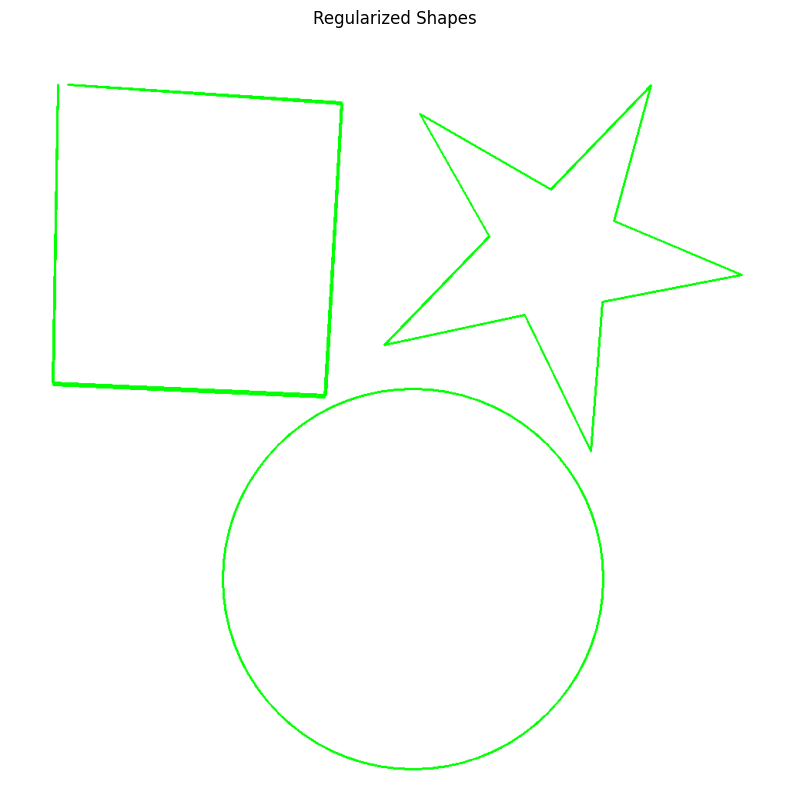

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from svgpathtools import svg2paths
from PIL import Image, ImageDraw

def svg_to_image(svg_file, output_size=(1000, 1000)):
    """Convert SVG file to a PIL image."""
    paths, attributes = svg2paths(svg_file)

    # Find the bounding box of the SVG
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        bounds = path.bbox()
        xmin, xmax = min(xmin, bounds[0]), max(xmax, bounds[1])
        ymin, ymax = min(ymin, bounds[2]), max(ymax, bounds[3])

    # Calculate scaling factor
    svg_width, svg_height = xmax - xmin, ymax - ymin
    scale = min(output_size[0] / svg_width, output_size[1] / svg_height) * 0.9  # 0.9 to add some padding

    # Calculate translation to center the image
    tx = (output_size[0] - svg_width * scale) / 2 - xmin * scale
    ty = (output_size[1] - svg_height * scale) / 2 - ymin * scale

    image = Image.new('RGB', output_size, (255, 255, 255))  # Create a white background image
    draw = ImageDraw.Draw(image)

    for path in paths:
        for segment in path:
            if segment.length() > 0:
                points = [segment.point(t) for t in np.linspace(0, 1, num=100)]
                scaled_points = [(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in points]
                draw.line(scaled_points, fill=(0, 0, 0), width=1)

    return np.array(image)

def is_star(contour):
    """Detect if a contour is a star shape."""
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    contour_area = cv2.contourArea(contour)

    solidity = float(contour_area) / hull_area
    if solidity < 0.5:
        angles = []
        for i in range(len(contour)):
            pt1 = contour[i][0]
            pt2 = contour[(i+1) % len(contour)][0]
            pt3 = contour[(i+2) % len(contour)][0]
            angle = np.abs(np.arctan2(pt3[1]-pt2[1], pt3[0]-pt2[0]) - np.arctan2(pt1[1]-pt2[1], pt1[0]-pt2[0]))
            angles.append(angle)

        is_alternating = all(angles[i] > angles[i+1] if i % 2 == 0 else angles[i] < angles[i+1] for i in range(len(angles)-1))
        return is_alternating

    return False

def regularize_shape(image, contour, shape_name):
    if shape_name == "Circle":
        (x, y), radius = cv2.minEnclosingCircle(contour)
        center = (int(x), int(y))
        radius = int(radius)
        cv2.circle(image, center, radius, (0, 255, 0), 2)
    elif shape_name in ["Square", "Rectangle"]:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    elif shape_name == "Star":
        hull = cv2.convexHull(contour, returnPoints=True)
        cv2.drawContours(image, [hull], 0, (0, 255, 0), 2)
    elif shape_name == "Polygon":
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(image, [approx], 0, (0, 255, 0), 2)

def detect_and_regularize_shapes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regularized_image = np.ones_like(image) * 255  # White background for regularized shapes

    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            if 0.95 <= aspect_ratio <= 1.05:
                shape_name = "Square"
            else:
                shape_name = "Rectangle"
        elif len(approx) == 5:
            shape_name = "Pentagon"
        elif len(approx) == 6:
            shape_name = "Hexagon"
        elif len(approx) > 6:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            circle_area = np.pi * radius * radius
            shape_area = cv2.contourArea(contour)
            if abs(circle_area - shape_area) / circle_area < 0.2:
                shape_name = "Circle"
            else:
                if is_star(contour):
                    shape_name = "Star"
                elif len(approx) > 4:
                    shape_name = "Polygon"
                else:
                    shape_name = "Unknown"
        else:
            shape_name = "Unknown"

        if shape_name in ["Circle", "Square", "Rectangle", "Star", "Pentagon", "Hexagon", "Polygon"]:
            regularize_shape(regularized_image, contour, shape_name)

    return regularized_image

def main(svg_file):
    # Convert SVG to image
    image = svg_to_image(svg_file)

    # Detect and regularize shapes in the image
    image_with_shapes = detect_and_regularize_shapes(image)

    # Show image with detected regularized shapes
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_with_shapes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Regularized Shapes")
    plt.show()

    # Save the regularized image
    cv2.imwrite('/content/regularized_image1.png', image_with_shapes)

if __name__ == "__main__":
    svg_file = '/content/isolated.svg'  # Replace with your SVG file path
    main(svg_file)

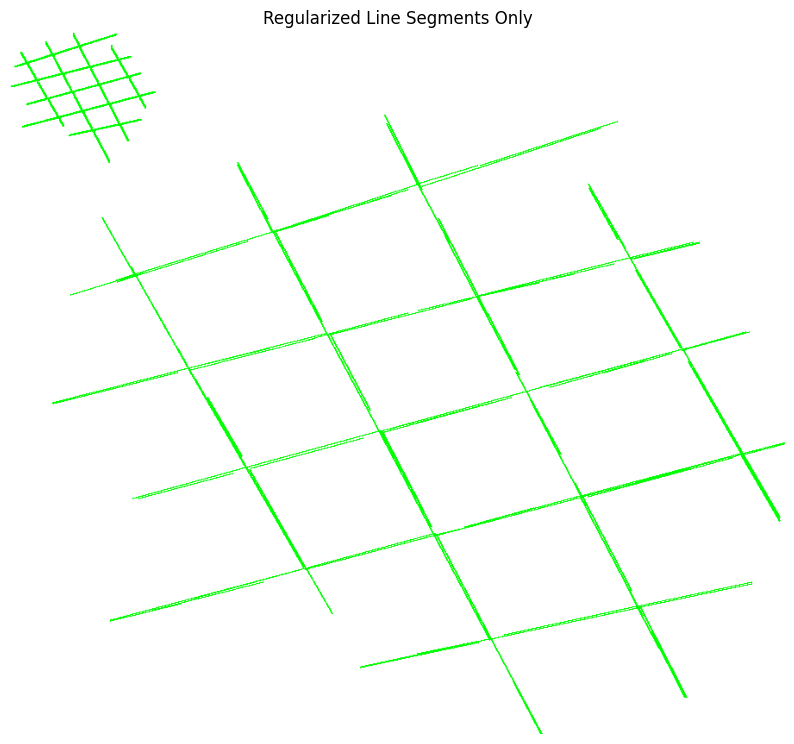

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from svgpathtools import svg2paths, Line, QuadraticBezier, CubicBezier
from PIL import Image, ImageDraw
from shapely.geometry import LineString
from shapely.ops import unary_union

def svg_to_image(svg_file, output_size=(1000, 1000)):
    """Convert SVG file to a PIL image."""
    paths, _ = svg2paths(svg_file)

    # Find the bounding box of the SVG
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        bounds = path.bbox()
        xmin, xmax = min(xmin, bounds[0]), max(xmax, bounds[1])
        ymin, ymax = min(ymin, bounds[2]), max(ymax, bounds[3])

    # Calculate scaling factor
    svg_width, svg_height = xmax - xmin, ymax - ymin
    scale = min(output_size[0] / svg_width, output_size[1] / svg_height) * 0.9  # 0.9 to add some padding

    # Calculate translation to center the image
    tx = (output_size[0] - svg_width * scale) / 2 - xmin * scale
    ty = (output_size[1] - svg_height * scale) / 2 - ymin * scale

    image = Image.new('RGB', output_size, (255, 255, 255))  # Create a white background image
    draw = ImageDraw.Draw(image)

    for path in paths:
        for segment in path:
            if segment.length() > 0:
                points = [segment.point(t) for t in np.linspace(0, 1, num=100)]
                scaled_points = [(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in points]
                draw.line(scaled_points, fill=(0, 0, 0), width=1)

    return image, paths, (svg_width, svg_height, scale, tx, ty)

def extract_line_segments(paths):
    """Extract line segments from paths."""
    line_segments = []
    for path in paths:
        for segment in path:
            if isinstance(segment, Line):
                points = [segment.start, segment.end]
                line_segments.append(LineString([(p.real, p.imag) for p in points]))
            elif isinstance(segment, QuadraticBezier):
                points = [segment.start, segment.control, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
            elif isinstance(segment, CubicBezier):
                points = [segment.start, segment.control1, segment.control2, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
    return line_segments

def approximate_bezier_curve(bezier, num_points=100):
    """Approximate a bezier curve with line segments."""
    t_values = np.linspace(0, 1, num_points)
    points = [bezier.point(t) for t in t_values]
    return [LineString([(p.real, p.imag) for p in points[i:i+2]]) for i in range(len(points) - 1)]

def detect_lines_hough(image):
    """Detect lines using Hough Transform."""
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)
    if lines is not None:
        line_segments = [LineString([(line[0][0], line[0][1]), (line[0][2], line[0][3])]) for line in lines]
        return line_segments
    return []

def merge_and_simplify_segments(line_segments):
    """Merge overlapping and intersecting line segments."""
    merged = unary_union(line_segments)
    return list(merged.geoms) if hasattr(merged, 'geoms') else [merged]

def draw_line_segments(image, line_segments):
    """Draw line segments on the image."""
    draw = ImageDraw.Draw(image)
    for line in line_segments:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            draw.line([coords[i], coords[i + 1]], fill=(0, 255, 0), width=2)

def main(svg_file):
    # Convert SVG to image
    _, paths, (svg_width, svg_height, scale, tx, ty) = svg_to_image(svg_file)

    # Extract line segments from paths
    line_segments = extract_line_segments(paths)

    # Detect lines using Hough Transform
    hough_lines = detect_lines_hough(_)

    # Merge and simplify all detected line segments
    all_lines = line_segments + hough_lines
    regularized_segments = merge_and_simplify_segments(all_lines)

    # Create a new blank image to draw the regularized shapes
    image_with_segments = Image.new('RGB', (int(svg_width * scale), int(svg_height * scale)), (255, 255, 255))

    # Draw regularized shapes on the new image
    draw_line_segments(image_with_segments, regularized_segments)

    # Show only the regularized image
    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(image_with_segments))
    plt.axis('off')
    plt.title("Regularized Line Segments Only")
    plt.show()

if __name__ == "__main__":
    svg_file = '/content/frag2.svg'  # Replace with your SVG file path
    main(svg_file)

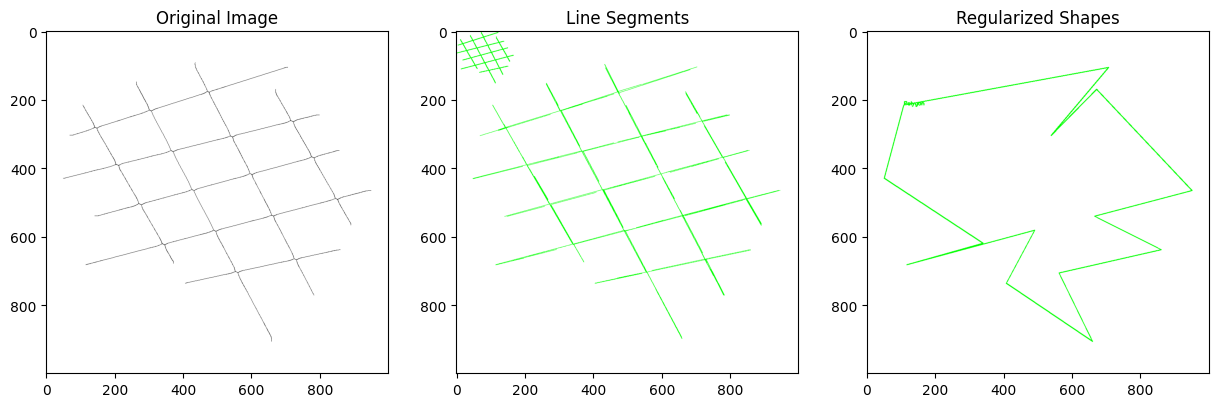

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from svgpathtools import svg2paths, Line, QuadraticBezier, CubicBezier
from PIL import Image, ImageDraw
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import unary_union

def svg_to_image(svg_file, output_size=(1000, 1000)):
    paths, _ = svg2paths(svg_file)
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        bounds = path.bbox()
        xmin, xmax = min(xmin, bounds[0]), max(xmax, bounds[1])
        ymin, ymax = min(ymin, bounds[2]), max(ymax, bounds[3])

    svg_width, svg_height = xmax - xmin, ymax - ymin
    scale = min(output_size[0] / svg_width, output_size[1] / svg_height) * 0.9

    tx = (output_size[0] - svg_width * scale) / 2 - xmin * scale
    ty = (output_size[1] - svg_height * scale) / 2 - ymin * scale

    image = Image.new('RGB', output_size, (255, 255, 255))
    draw = ImageDraw.Draw(image)

    for path in paths:
        for segment in path:
            if segment.length() > 0:
                points = [segment.point(t) for t in np.linspace(0, 1, num=100)]
                scaled_points = [(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in points]
                draw.line(scaled_points, fill=(0, 0, 0), width=1)

    return np.array(image), paths

def extract_line_segments(paths):
    line_segments = []
    for path in paths:
        for segment in path:
            if isinstance(segment, Line):
                points = [segment.start, segment.end]
                line_segments.append(LineString([(p.real, p.imag) for p in points]))
            elif isinstance(segment, QuadraticBezier):
                points = [segment.start, segment.control, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
            elif isinstance(segment, CubicBezier):
                points = [segment.start, segment.control1, segment.control2, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
    return line_segments

def approximate_bezier_curve(bezier, num_points=100):
    t_values = np.linspace(0, 1, num_points)
    points = [bezier.point(t) for t in t_values]
    return [LineString([(p.real, p.imag) for p in points[i:i+2]]) for i in range(len(points) - 1)]

def detect_lines_hough(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)
    if lines is not None:
        line_segments = [LineString([(line[0][0], line[0][1]), (line[0][2], line[0][3])]) for line in lines]
        return line_segments
    return []

def merge_and_simplify_segments(line_segments):
    merged = unary_union(line_segments)
    return list(merged.geoms) if hasattr(merged, 'geoms') else [merged]

def draw_line_segments(image, line_segments):
    draw = ImageDraw.Draw(image)
    for line in line_segments:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            draw.line([coords[i], coords[i + 1]], fill=(0, 255, 0), width=2)

def detect_and_regularize_shapes(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    regularized_image = np.ones_like(image) * 255

    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            if 0.95 <= aspect_ratio <= 1.05:
                shape_name = "Square"
            else:
                shape_name = "Rectangle"
        elif len(approx) == 5:
            shape_name = "Pentagon"
        elif len(approx) == 6:
            shape_name = "Hexagon"
        elif len(approx) > 6:
            (x, y), radius = cv2.minEnclosingCircle(contour)
            circle_area = np.pi * radius * radius
            shape_area = cv2.contourArea(contour)
            if abs(circle_area - shape_area) / circle_area < 0.2:
                shape_name = "Circle"
            else:
                if is_star(contour):
                    shape_name = "Star"
                elif len(approx) > 4:
                    shape_name = "Polygon"
                else:
                    shape_name = "Unknown"
        else:
            shape_name = "Unknown"

        if shape_name in ["Circle", "Square", "Rectangle", "Star", "Pentagon", "Hexagon", "Polygon"]:
            regularize_shape(regularized_image, contour, shape_name)
            cv2.putText(regularized_image, shape_name, tuple(approx[0][0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return regularized_image

def is_star(contour):
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    contour_area = cv2.contourArea(contour)

    solidity = float(contour_area) / hull_area
    if solidity < 0.5:
        angles = []
        for i in range(len(contour)):
            pt1 = contour[i][0]
            pt2 = contour[(i+1) % len(contour)][0]
            pt3 = contour[(i+2) % len(contour)][0]
            angle = np.abs(np.arctan2(pt3[1]-pt2[1], pt3[0]-pt2[0]) - np.arctan2(pt1[1]-pt2[1], pt1[0]-pt2[0]))
            angles.append(angle)

        is_alternating = all(angles[i] > angles[i+1] if i % 2 == 0 else angles[i] < angles[i+1] for i in range(len(angles)-1))
        return is_alternating

    return False

def regularize_shape(image, contour, shape_name):
    if shape_name == "Circle":
        (x, y), radius = cv2.minEnclosingCircle(contour)
        center = (int(x), int(y))
        radius = int(radius)
        cv2.circle(image, center, radius, (0, 255, 0), 2)
    elif shape_name in ["Square", "Rectangle"]:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    elif shape_name == "Star":
        hull = cv2.convexHull(contour, returnPoints=True)
        cv2.drawContours(image, [hull], 0, (0, 255, 0), 2)
    elif shape_name == "Polygon":
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(image, [approx], 0, (0, 255, 0), 2)

def main(svg_file):
    image, paths = svg_to_image(svg_file)

    line_segments = extract_line_segments(paths)
    hough_lines = detect_lines_hough(image)
    all_lines = line_segments + hough_lines
    regularized_segments = merge_and_simplify_segments(all_lines)

    image_with_segments = Image.new('RGB', image.shape[1::-1], (255, 255, 255))
    draw_line_segments(image_with_segments, regularized_segments)

    regularized_shapes_image = detect_and_regularize_shapes(image)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(image)
    plt.subplot(1, 3, 2)
    plt.title('Line Segments')
    plt.imshow(image_with_segments)
    plt.subplot(1, 3, 3)
    plt.title('Regularized Shapes')
    plt.imshow(regularized_shapes_image)
    plt.show()

svg_file = '/content/frag2.svg'
main(svg_file)

*(Above code will need to be edited to fit the complex test case)*

#STEP 2: SYMMETRY

*(Output generated from Step 1 is .png -> Currently, we convert it to .svg using an external converter to use .svg input for Step 2. Code for it will be added later)*

In [ ]:
import numpy as np
from svgpathtools import svg2paths, Line, QuadraticBezier, CubicBezier
from shapely.geometry import LineString, Point
from shapely.ops import unary_union
from scipy.optimize import minimize
from scipy.spatial.distance import euclidean
from PIL import Image, ImageDraw

def svg_to_image(svg_file, output_size=(1000, 1000)):
    """Convert SVG file to a PIL image."""
    paths, _ = svg2paths(svg_file)

    # Find the bounding box of the SVG
    xmin, xmax, ymin, ymax = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        bounds = path.bbox()
        xmin, xmax = min(xmin, bounds[0]), max(xmax, bounds[1])
        ymin, ymax = min(ymin, bounds[2]), max(ymax, bounds[3])

    # Calculate scaling factor
    svg_width, svg_height = xmax - xmin, ymax - ymin
    scale = min(output_size[0] / svg_width, output_size[1] / svg_height) * 0.9  # 0.9 to add some padding

    # Calculate translation to center the image
    tx = (output_size[0] - svg_width * scale) / 2 - xmin * scale
    ty = (output_size[1] - svg_height * scale) / 2 - ymin * scale

    image = Image.new('RGB', output_size, (255, 255, 255))  # Create a white background image
    draw = ImageDraw.Draw(image)

    for path in paths:
        for segment in path:
            if segment.length() > 0:
                points = [segment.point(t) for t in np.linspace(0, 1, num=100)]
                scaled_points = [(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in points]
                draw.line(scaled_points, fill=(0, 0, 0), width=1)

    return image, paths, (svg_width, svg_height, scale, tx, ty)

def extract_line_segments(paths):
    """Extract line segments from SVG paths."""
    line_segments = []
    for path in paths:
        for segment in path:
            if isinstance(segment, Line):
                points = [segment.start, segment.end]
                line_segments.append(LineString([(p.real, p.imag) for p in points]))
            elif isinstance(segment, QuadraticBezier):
                points = [segment.start, segment.control, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
            elif isinstance(segment, CubicBezier):
                points = [segment.start, segment.control1, segment.control2, segment.end]
                line_segments.extend(approximate_bezier_curve(segment, num_points=100))
    return line_segments

def approximate_bezier_curve(bezier, num_points=100):
    """Approximate a bezier curve with line segments."""
    t_values = np.linspace(0, 1, num_points)
    points = [bezier.point(t) for t in t_values]
    return [LineString([(p.real, p.imag) for p in points[i:i+2]]) for i in range(len(points) - 1)]

def detect_symmetry(line_segments):
    """Detect symmetry in line segments."""
    symmetric_segments = []

    # Example: Checking for mirror symmetry along the x-axis
    for segment in line_segments:
        mirrored_segment = LineString([(p[0], -p[1]) for p in segment.coords])
        if mirrored_segment.is_valid and mirrored_segment in line_segments:
            symmetric_segments.append(segment)

    return symmetric_segments

def fit_bezier_curve(points):
    """Fit a Bézier curve to a set of points."""
    # Define an initial guess or starting control points
    initial_guess = np.array(points)  # Initial control points, adjust as needed

    # Define a cost function to minimize (e.g., Euclidean distance)
    def cost_function(control_points):
        # Generate points from the Bézier curve defined by control_points
        curve_points = bezier_curve(control_points, num_points=100)  # Implement bezier_curve function

        # Calculate the error (distance) between curve_points and points
        error = np.sum([euclidean(curve_points[i], points[i]) for i in range(len(points))])
        return error

    # Minimize the cost function to find optimal control points
    result = minimize(cost_function, initial_guess, method='Nelder-Mead')

    # Extract optimal control points
    optimal_control_points = result.x

    return optimal_control_points

def bezier_curve(control_points, num_points=100):
    """Generate points on a Bézier curve given control points."""
    t_values = np.linspace(0, 1, num_points)
    curve_points = []
    for t in t_values:
        point = np.zeros_like(control_points[0])
        n = len(control_points) - 1
        for i, cp in enumerate(control_points):
            point += np.math.factorial(n) / (np.math.factorial(i) * np.math.factorial(n - i)) * (1 - t)**(n - i) * t**i * cp
        curve_points.append(point)
    return curve_points

def segment_and_fit_symmetric_curves(line_segments):
    """Segment and fit Bézier curves on symmetric segments."""
    fitted_curves = []
    for segment in line_segments:
        points = list(segment.coords)
        fitted_curve_control_points = fit_bezier_curve(points)
        fitted_curves.append(fitted_curve_control_points)

    return fitted_curves

def main(svg_file):
    # Convert SVG to image and extract line segments
    image, paths, (svg_width, svg_height, scale, tx, ty) = svg_to_image(svg_file)
    line_segments = extract_line_segments(paths)

    # Detect symmetry in line segments
    symmetric_segments = detect_symmetry(line_segments)

    # Fit identical Bézier curves on symmetric segments
    fitted_curves = segment_and_fit_symmetric_curves(symmetric_segments)

    # Create a new blank image to draw the regularized shapes
    image_with_curves = Image.new('RGB', (int(svg_width * scale), int(svg_height * scale)), (255, 255, 255))
    draw = ImageDraw.Draw(image_with_curves)

    # Draw original shapes with fitted Bézier curves
    for segment, curve_points in zip(symmetric_segments, fitted_curves):
        draw.line([(int(p.real * scale + tx), int(p.imag * scale + ty)) for p in bezier_curve(curve_points)], fill=(0, 255, 0), width=2)

    # Show only the regularized image with fitted curves
    image_with_curves.show()

if __name__ == "__main__":
    svg_file = '/content/regularized_image1.svg'  # Replace with your SVG file path
    main(svg_file)